# Gradient descent:

In [2]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
x,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13) 

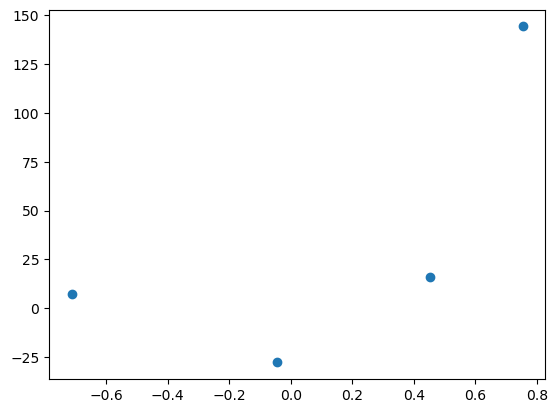

In [5]:
plt.scatter(x,y)

**Step 1: Lets apply OLS:** to find slope and intercept already

In [6]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [7]:
reg.coef_

array([78.35063668])

In [8]:
reg.intercept_

np.float64(26.15963284313262)

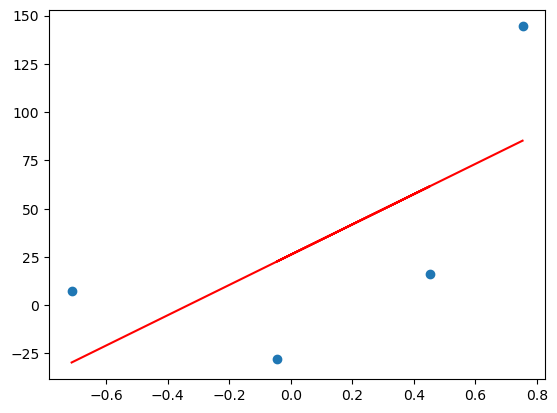

In [9]:
plt.scatter(x,y)
plt.plot(x,reg.predict(x),color= "red")

**Step 2: Lets apply Gradient Descent assuming slope: m = 78.35 and assuming starting value of intercept: c = 0**

In [15]:
y_pred = (78.35 * x + 0).reshape(4)     # by putting in general formula

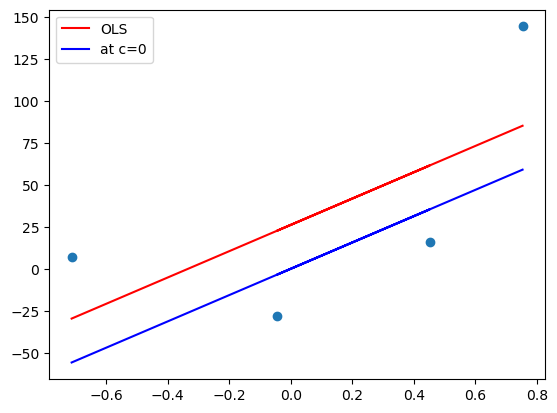

In [14]:
plt.scatter(x,y)
plt.plot(x, reg.predict(x), color="red", label="OLS")
plt.plot(x,y_pred, color="blue", label="at c=0")
plt.legend()
plt.show()

In [25]:
m = 78.35
c = 0
loss_slope = -2 * np.sum( y - m*x.ravel() - c)     # using equation 1
loss_slope

np.float64(-209.27763408209216)

In [19]:
# lets take learning rate = 0.1

lr =0.1
step_size = loss_slope*lr
step_size

np.float64(-20.927763408209216)

In [27]:
# Now calculate new intercept: using equation 2:

c = c - step_size
c

np.float64(20.927763408209216)

In [34]:
y_pred1 = (78.35*x + c).reshape(4)    # to again plot for next iterations
y_pred1

array([-30.70249228,  60.51281283,  21.6264999 ,  84.17091186])

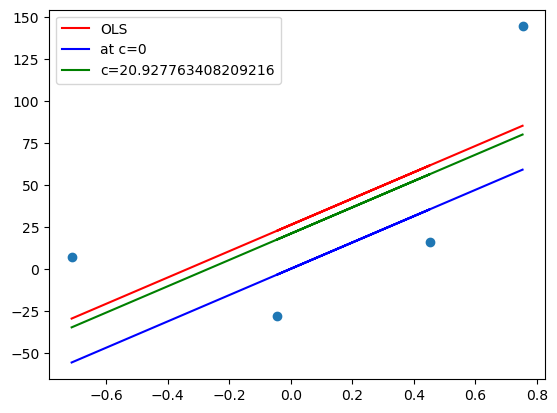

In [29]:
plt.scatter(x,y)
plt.plot(x, reg.predict(x), color="red", label="OLS")
plt.plot(x, y_pred, color="blue", label="at c=0")
plt.plot(x, y_pred1, color="green", label = "c={}".format(c)) 
plt.legend()
plt.show()

In [30]:
#Iteration 2:

loss_slope = -2 * np.sum( y - m*x.ravel() - c)     # using equation 1
loss_slope

np.float64(-41.85552681641843)

In [31]:
step_size = loss_slope*lr
step_size

np.float64(-4.185552681641844)

In [32]:
c = c - step_size
c

np.float64(25.11331608985106)

In [35]:
y_pred2 = (78.35*x + c).reshape(4)
y_pred2

array([-30.70249228,  60.51281283,  21.6264999 ,  84.17091186])

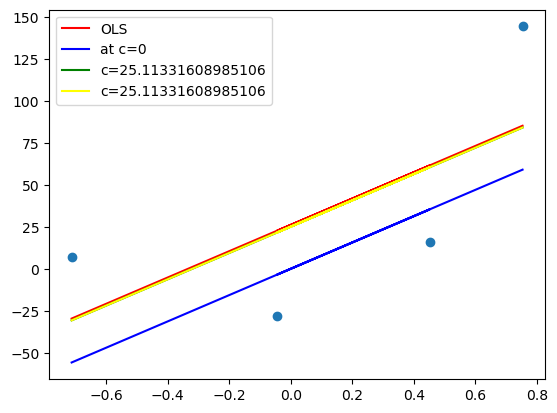

In [36]:
plt.scatter(x,y)
plt.plot(x, reg.predict(x), color="red", label="OLS")
plt.plot(x, y_pred, color="blue", label="at c=0")
plt.plot(x, y_pred1, color="green", label = "c={}".format(c)) 
plt.plot(x, y_pred2, color="yellow", label = "c={}".format(c)) 
plt.legend()
plt.show()

**jitni iterations hum badate jaayenge utna hi correct approach fillow krenge**

**method 2: using loops in epochs for n number of iterations** 

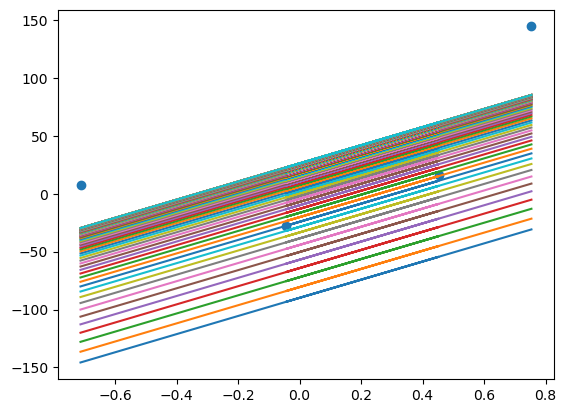

In [39]:
c = -100
m = 78.35
lr = 0.01
epochs = 100

for i in range(epochs):
    loss_slope = -2 * np.sum( y - m*x.ravel() - c)
    step_size = loss_slope*lr
    c = c - step_size
    y_pred = 78.35 * x + c

    plt.plot(x,y_pred)
plt.scatter(x,y)

# -> now make custom class for gradient descent implementation

In [50]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

In [51]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20) 

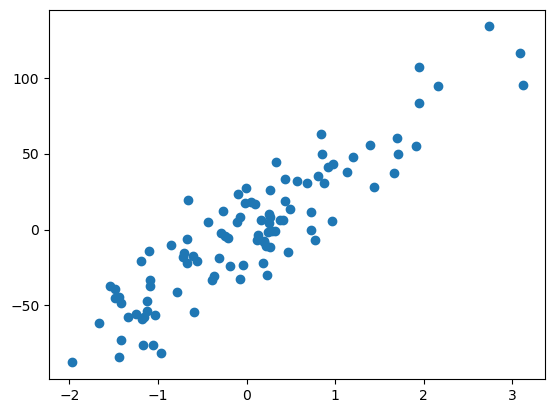

In [24]:
plt.scatter(x,y)

In [25]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)
print(lr.coef_)
print(lr.intercept_)

[37.75322732]
-2.2356030784492043


**Case1: now we are gonna fix the slope and make class jo intercept calculate krke dega which should closer to -2.23 (given)**

In [44]:
m = 37.75

In [35]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.m = 37.75
        self.c = -120
        self.lr = learning_rate
        self.epochs = epochs 

    def fit(self,x,y):
        #calculate value of c using gradient descent:
        for i in range(self.epochs):
            loss_slope = -2 * np.sum( y - self.m * x.ravel() - self.c)
            step_size = loss_slope * self.lr
            self.c = self.c - step_size
        print(self.c)

In [40]:
gd = GDRegressor(0.01,10)      # learning rate = 0.01, epochs = 10

In [41]:
gd.fit(x,y)

-119.99999999999991


**yeh c bilkul bhi change nhi hua as humne -120 liya tha for reference but hamein -2.23 chahiye tha yn closer to it: so in this case aap learning_rate ko aur kam krdo and epochs ko aur badado**

In [42]:
gd = GDRegressor(0.001,100)      # learning rate = 0.01, epochs = 10

In [45]:
gd.fit(x,y)   #now it matches with original c (intercept) value jo hamein chahiye thi

-2.235475448196714


**Case2: Now calculate both m and c using gradient descent:**

In [134]:
from sklearn.datasets import make_regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1, noise=20) 

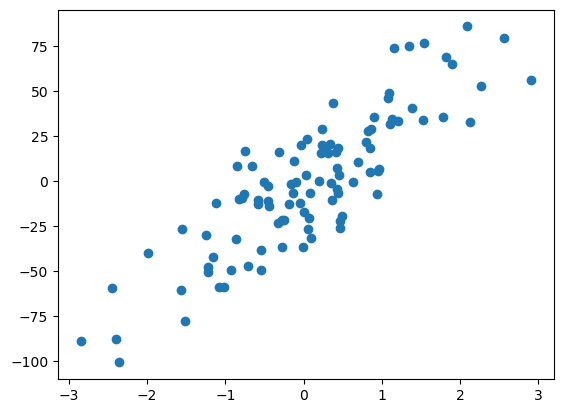

In [136]:
plt.scatter(x,y)

In [137]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x,y)
print(lr.coef_)
print(lr.intercept_)

[29.83717598]
-3.2594959324147337


**now m and c both variables we have to find**

In [138]:
class GDRegressor:
    def __init__(self, learning_rate, epochs):
        self.m = 100     # just initialise m with any random value
        self.c = -120     ## just initialise c with any random value
        self.lr = learning_rate
        self.epochs = epochs 

    def fit(self,x,y):
        #calculate value of m and c using gradient descent:
        for i in range(self.epochs):
            loss_slope_c = -2 * np.sum( y - self.m * x.ravel() - self.c)
            loss_slope_m = -2 * np.sum(( y - self.m * x.ravel() - self.c) * x.ravel())
            
            self.c = self.c - (loss_slope_c * self.lr)
            self.m = self.m - (loss_slope_m * self.lr)
        print(self.m, self.c)

    def predict(self, x):
        return self.m * x + self.c 

In [153]:
gd = GDRegressor(0.001,50) 

In [154]:
gd.fit(x,y)

29.838146884735337 -3.2621122274268037


In [155]:
y_pred = gd.predict(x)
r2_score(y_test,y_pred)

NameError: name 'r2_score' is not defined